In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

color_pal = sns.color_palette()

In [122]:
df = pd.read_csv("data.csv")

Removed unnamed column and changed names. Added datetime as index.

In [123]:
# drop unnamed
df.drop(columns=["Unnamed: 0"], inplace=True)

In [124]:
df.rename(columns={'date': 'datetime'}, inplace=True)
df.rename(columns={'precipitation': 'precipitation(mm)'}, inplace=True)

In [125]:
# remove the time zone aware part of datetime
df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)

In [126]:
df = df.set_index("datetime")

Visualizes the soil moisture and precipitation over time.

<Figure size 1500x500 with 0 Axes>

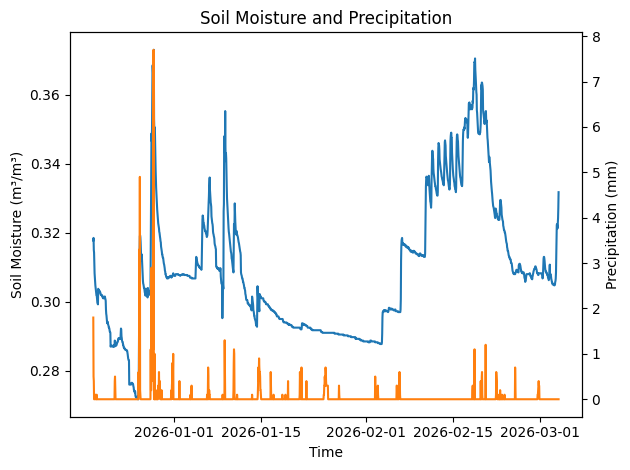

In [127]:
plt.figure(figsize=(15, 5))
fig, ax1 = plt.subplots()

ax1.plot(df.index, df["soil_moisture(m^3/m^3)"])
ax1.set_xlabel("Time")
ax1.set_ylabel("Soil Moisture (m³/m³)")

ax2 = ax1.twinx()
ax2.plot(df.index, df["precipitation(mm)"], color=color_pal[1])
ax2.set_ylabel("Precipitation (mm)")

plt.title("Soil Moisture and Precipitation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this graph, we can see the spike in precipitation at the beginning lead to higher levels of soil moisture. They are somewhat correlated, but it might not be a linear relationship

In [128]:
'''
Creates the features used for our model

Time Features: includes the hour, day, month, year, and quarter

sm_rolling: this is the rolling average of soil moisture taken in the specified amount of hours
before the current soil moisture. This argument is defaulted to 24 hours

rain_weighted: The weighted mean of precipitation over a specified period. The default is 24 and
the more recent rainfall values are weighted more.

target: gets the future soil moisture values over a specified period. The default is the next
24 hours (target is an array)
'''

def create_features(df, horizon=24, rain_window=24, sm_window=24):
    df = df.copy()

    # gets all time information
    df["hour"] = df.index.hour
    df["day"] = df.index.dayofweek
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["quarter"] = df.index.quarter

    df[f"sm_rolling_{sm_window}h(m^3/m^3)"] = df['soil_moisture(m^3/m^3)'].rolling(window=sm_window).mean().shift(1)
    df[f"rain_weighted_{rain_window}h(mm)"] = df["precipitation(mm)"].ewm(span=rain_window).mean().shift(1)
    
    # gets the target soil moisture values
    for lag in range(1, horizon+1):
        df[str(lag)] = df["soil_moisture(m^3/m^3)"].shift(-lag)

    cols = [str(i) for i in range(1, horizon+1)]
    df["target"] = list(df[cols].values)
    df.drop(columns=cols, inplace=True)
    mask = df["target"].apply(lambda x: not np.isnan(x).any())
    return df[mask].dropna()

In [129]:
horizon = 6
df = create_features(df, horizon=horizon)

<Axes: xlabel='rain_weighted_24h(mm)', ylabel='soil_moisture(m^3/m^3)'>

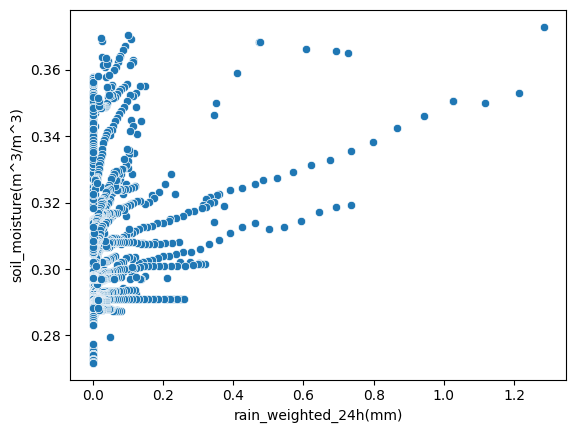

In [130]:
# interaction between precipitation and soil moisture
sns.scatterplot(df, x='rain_weighted_24h(mm)', y='soil_moisture(m^3/m^3)')

Dataset used for model training

In [131]:
df

,soil_moisture(m^3/m^3),precipitation(mm),hour,day,month,year,quarter,sm_rolling_24h(m^3/m^3),rain_weighted_24h(mm),target
datetime,,,,,,,,,,
2025-12-20 00:00:00,0.30300,0.0,0,5,12,2025,4,0.305562,0.049621,"[0.303, 0.30275, 0.30275, 0.30225, 0.30200002,..."
2025-12-20 01:00:00,0.30300,0.0,1,5,12,2025,4,0.304948,0.045087,"[0.30275, 0.30275, 0.30225, 0.30200002, 0.3020..."
2025-12-20 02:00:00,0.30275,0.0,2,5,12,2025,4,0.304302,0.041014,"[0.30275, 0.30225, 0.30200002, 0.30200002, 0.3..."
2025-12-20 03:00:00,0.30275,0.0,3,5,12,2025,4,0.303792,0.037347,"[0.30225, 0.30200002, 0.30200002, 0.30200002, ..."
2025-12-20 04:00:00,0.30225,0.0,4,5,12,2025,4,0.303312,0.034039,"[0.30200002, 0.30200002, 0.30200002, 0.3020000..."
...,...,...,...,...,...,...,...,...,...,...
2026-03-03 13:00:00,0.30850,0.0,13,1,3,2026,1,0.306115,0.000546,"[0.31275, 0.31825, 0.32225, 0.3225, 0.32175, 0..."
2026-03-03 14:00:00,0.31275,0.0,14,1,3,2026,1,0.306021,0.000502,"[0.31825, 0.32225, 0.3225, 0.32175, 0.32125, 0..."
2026-03-03 15:00:00,0.31825,0.0,15,1,3,2026,1,0.306229,0.000462,"[0.32225, 0.3225, 0.32175, 0.32125, 0.3225, 0...."


There seems to be a slight linear relationship with soil moisture and weighted precipitation for the higher soil moisture values

In [132]:
model = RandomForestRegressor(random_state=42)

In [133]:
# partition data into train and test sets

# get 80% split
split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop(columns=['target'])
y_train = np.stack(train['target'].values)

X_test = test.drop(columns=['target'])
y_test = np.stack(test['target'].values)

In [134]:
# cross validation for model performance evaluation

cv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(model, df.drop(columns=['target']), np.stack(df['target'].values), cv=cv, scoring='neg_root_mean_squared_error')

for i, score in enumerate(scores, 1):
    print(f"Fold {i} RMSE: {-score:.6f}")

print(f"Average RMSE: {-np.mean(scores)}")
print(f"Standard Deviation: {np.std(scores)}")

Fold 1 RMSE: 0.009094
Fold 2 RMSE: 0.003494
Fold 3 RMSE: 0.002301
Fold 4 RMSE: 0.010382
Fold 5 RMSE: 0.003613
Average RMSE: 0.005776872606463706
Standard Deviation: 0.0032921856726962763


Given that the range of soil moisture is 0.1, this is pretty good

In [135]:
# Normalized RMSE
-np.mean(scores) / (df['soil_moisture(m^3/m^3)'].max() - df['soil_moisture(m^3/m^3)'].min())

np.float64(0.057055531915690925)

The error rate is on average 5% of the total range of soil moisture values

In [136]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [137]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

soil_moisture(m^3/m^3)     0.942963
sm_rolling_24h(m^3/m^3)    0.022882
rain_weighted_24h(mm)      0.013966
hour                       0.008514
precipitation(mm)          0.005738
day                        0.004183
month                      0.000962
quarter                    0.000450
year                       0.000342
dtype: float64

In [138]:
predictions = model.predict(X_test)

In [139]:
print(f"Testing Error: {root_mean_squared_error(y_test, predictions)}")
print(f"Training Error: {root_mean_squared_error(y_train, model.predict(X_train))}")
print(f"R^2 Score: {r2_score(y_test, predictions)}")

Testing Error: 0.004781513507655073
Training Error: 0.0011852423437661386
R^2 Score: 0.9368621901768132


Our test error is low so our model most likely isn't overfitting which is good. 93% of the variance in our testing data is captured by our model

Residuals for each hour seem to be distributed the same

In [140]:
# calculate average residuals across hours
for i in range(0, horizon):
    print(f"Average Residual (+{i+1}): {np.mean(y_test[:, i] - predictions[:, i])}")

Average Residual (+1): 0.0012174434101675652
Average Residual (+2): 0.0010587989585056337
Average Residual (+3): 0.0008446606521025917
Average Residual (+4): 0.00041194195645756124
Average Residual (+5): 0.0002116029421449722
Average Residual (+6): -0.00034863690052925624


Pretty good residuals all around for each of the hours

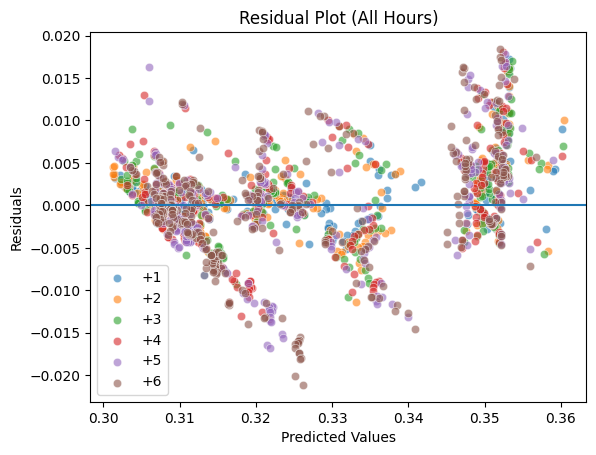

In [141]:
residuals = y_test - predictions
n_targets = y_test.shape[1]

plt.figure()

for i in range(n_targets):
    sns.scatterplot(
        x=predictions[:, i],
        y=residuals[:, i],
        label=f"+{i+1}",
        alpha=0.6
    )

plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (All Hours)")
plt.legend()
plt.show()

For higher predicted soil moisture values, The actual soil moisture values are higher. For lower predicted soil moisture values, the actual soil moisture values are lower generally speaking

In [142]:
# This code turns the predicted and actual array targets into singular arrays
actual = list(y_test[0])
for i in range(1, len(y_test)):
    actual.append(y_test[i, -1])

predicted = list(predictions[0])
for i in range(1, len(predictions)):
    predicted.append(predictions[i, -1])

actual = np.array(actual)
predicted = np.array(predicted)

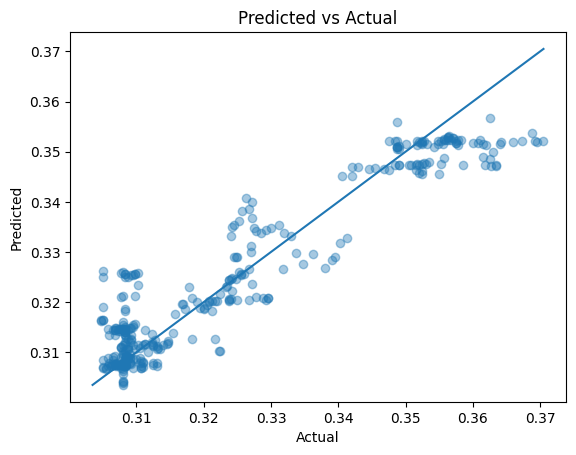

In [143]:
# visualizes the residuals
y_true = actual.flatten()
y_pred = predicted.flatten()

plt.figure()
plt.scatter(y_true, y_pred, alpha=0.4)

# 45-degree reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

Higher predicted soil moisture values lead to an underprediction by the model.

Lower predicted soil moisture values generally lead to an overprediction by the model.

This confirms what we saw in the earlier residual plot.

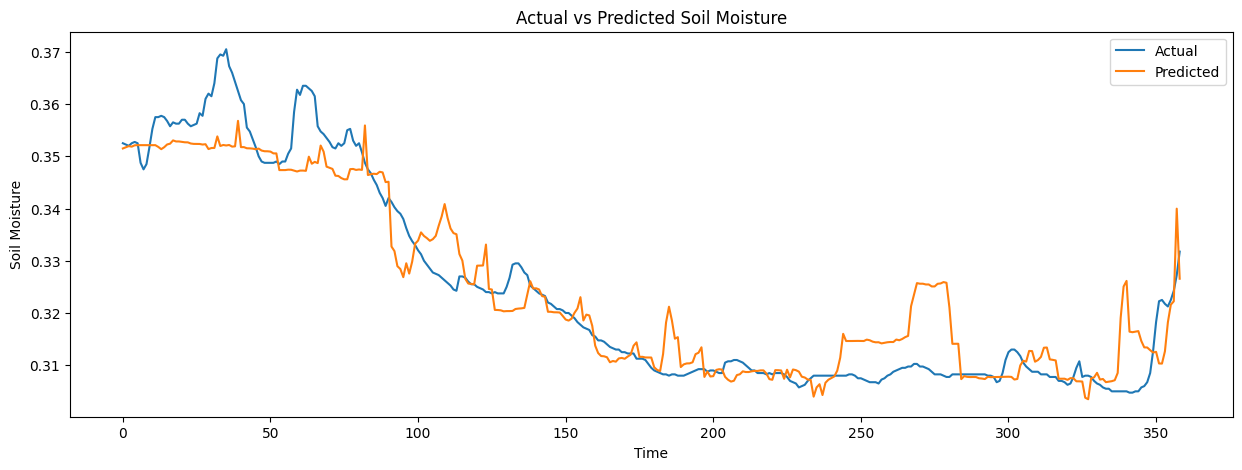

In [144]:
plt.figure(figsize=(15,5))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.xlabel("Time")
plt.ylabel("Soil Moisture")
plt.title("Actual vs Predicted Soil Moisture")
plt.legend()
plt.show()